# Telegram Channel Intelligence Playbook
This notebook implements a comprehensive intelligence framework for analyzing Telegram channels, focusing on identity, behavior, content, and network position.

In [1]:
# @title 0. Environment Setup
!pip install -q telethon pandas matplotlib seaborn pyarrow fastparquet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from telethon.sync import TelegramClient
from telethon.sessions import StringSession
from telethon.tl.functions.channels import GetFullChannelRequest
from google.colab import userdata

# Configuration
API_ID = userdata.get('API_ID')
API_HASH = userdata.get('API_HASH')
SESSION_STR = userdata.get('TELEGRAM_SESSION')
PARQUET_FILE = 'data/telegram_raw.parquet'

# Initialize Client
try:
    client = TelegramClient(StringSession(SESSION_STR.strip()), int(API_ID), API_HASH)
    print("✅ Telegram Client initialized successfully.")
except Exception as e:
    print(f"❌ Failed to initialize client: {e}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.8/789.8 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.7 MB/s eta 0:00:00
✅ Telegram Client initialized successfully.


In [2]:
!pip install -q langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import os

# @title 1. Data Ingestion
channel_handle = "me_observer_TG" # @param {type:"string"}
num_to_scrape = 1000 # @param {type:"slider", min:100, max:10000, step:100}

async def fetch_messages(channel, limit):
    # Ensure the directory exists
    dir_path = os.path.dirname(PARQUET_FILE)
    if dir_path and not os.path.exists(dir_path):
        os.makedirs(dir_path)

    await client.start()
    print(f"Starting ingestion: {limit} messages from {channel}...")

    messages_list = []
    count = 0

    async for message in client.iter_messages(channel, limit=limit):
        if count % 200 == 0 and count > 0:
            print(f"Extracted {count} messages...")
            time.sleep(1)

        messages_list.append({
            "id": message.id,
            "date": message.date,
            "sender_id": message.sender_id,
            "text": message.text,
            "media_type": type(message.media).__name__ if message.media else "text",
            "views": message.views,
            "forwards": message.forwards,
            "reply_to_id": message.reply_to_msg_id
        })
        count += 1

    df = pd.DataFrame(messages_list)
    df.to_parquet(PARQUET_FILE, index=False)
    print(f"✅ Success: {len(df)} messages saved to {PARQUET_FILE}.")
    return df

if channel_handle:
    # Use await directly in Colab
    df_raw = await fetch_messages(channel_handle, num_to_scrape)
    display(df_raw.head())
else:
    print("⚠️ Please enter a channel handle to begin.")

Starting ingestion: 1000 messages from me_observer_TG...
Extracted 200 messages...
Extracted 400 messages...
Extracted 600 messages...
Extracted 800 messages...
✅ Success: 1000 messages saved to data/telegram_raw.parquet.


,id,date,sender_id,text,media_type,views,forwards,reply_to_id
0,1058500,2026-07-30 23:47:40+00:00,-1001545920165,⚡️ Palestinian sources: The occupation army fi...,text,32,0,NaN
1,1058499,2026-07-30 23:43:30+00:00,-1001545920165,,MessageMediaDocument,93,1,NaN
2,1058498,2026-07-30 23:43:30+00:00,-1001545920165,,MessageMediaDocument,90,1,NaN
3,1058497,2026-07-30 23:43:30+00:00,-1001545920165,⚡️ Drone strikes hit separatist party sites in...,MessageMediaDocument,89,1,NaN
4,1058496,2026-07-30 23:40:32+00:00,-1001545920165,"⚡️ *In the name of Allah, the Most Gracious, t...",text,113,1,NaN


In [4]:
import os

if os.path.exists(PARQUET_FILE):
    print(f"✅ Found: {PARQUET_FILE} exists in /content/")
    # List file details
    stats = os.stat(PARQUET_FILE)
    print(f"Size: {stats.st_size / 1024:.2f} KB")
else:
    print(f"❌ Not Found: {PARQUET_FILE} has not been created yet.")
    print("Please enter a channel handle in the 'Data Ingestion' cell above and run it.")

✅ Found: data/telegram_raw.parquet exists in /content/
Size: 182.82 KB


# 1. Identity Profile
In this section, we extract the metadata and attribution indicators for the target channel.

In [5]:
# @title 2. Identity Profile
async def get_identity_profile(channel):
    await client.start()
    entity = await client.get_entity(channel)
    full_channel = await client(GetFullChannelRequest(channel=entity))

    profile = {
        "Channel Name": entity.title,
        "Username": entity.username,
        "ID": entity.id,
        "Subscriber Count": full_channel.full_chat.participants_count,
        "Creation Date": entity.date,
        "Description": full_channel.full_chat.about,
        "Linked Chat ID": full_channel.full_chat.linked_chat_id
    }
    return pd.DataFrame([profile])

if 'channel_handle' in locals() and channel_handle:
    # Use await directly in Colab
    df_profile = await get_identity_profile(channel_handle)
    print("--- Channel Identity Profile ---")
    display(df_profile)
else:
    print("⚠️ Ingest a channel first to view its identity profile.")

--- Channel Identity Profile ---


,Channel Name,Username,ID,Subscriber Count,Creation Date,Description,Linked Chat ID
0,Middle East Observer,me_observer_TG,1545920165,39222,2023-10-16 04:21:39+00:00,🚨Notice :\nI am not the one writing the messag...,1906022106


In [6]:
import os

# Create directory
output_dir = 'Findings/identity'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define file path
md_file_path = os.path.join(output_dir, 'identity_profile.md')

# Convert df_profile to markdown and save
if 'df_profile' in locals():
    md_content = "# Channel Identity Profile\n\n" + df_profile.T.to_markdown()
    with open(md_file_path, 'w') as f:
        f.write(md_content)
    print(f"✅ Identity profile exported to: {md_file_path}")
else:
    print("⚠️ No profile data found. Please run the Identity Profile cell first.")

✅ Identity profile exported to: Findings/identity/identity_profile.md


# 1.2 Attribution & External Footprint Analysis
This section deep-dives into writing styles, external social media links, and audience alignment found within the message data.

In [7]:
import re
from collections import Counter

def analyze_forensics(df):
    # 1. External Footprint (Regex for social media and web)
    text_blob = " ".join(df['text'].dropna().astype(str))
    links = {
        "X/Twitter": list(set(re.findall(r'twitter\.com/\w+|x\.com/\w+', text_blob))),
        "YouTube": list(set(re.findall(r'youtube\.com/\w+|youtu\.be/\w+', text_blob))),
        "Websites": list(set(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text_blob)))[:15]
    }

    # 2. Attribution Indicators (Admin signatures and common patterns)
    signatures = re.findall(r'\n\s*(@\w+)', text_blob)
    top_sigs = Counter(signatures).most_common(5)

    # 3. Timezone Indicators (Peak hour in UTC helps infer location)
    df['hour'] = df['date'].dt.hour
    peak_hour = df['hour'].mode()[0]

    # 4. Forensics Report Construction
    report = f"# Identity Forensics: {channel_handle}\n\n"
    report += "## Attribution Indicators\n"
    report += f"- **Peak Activity (UTC):** {peak_hour}:00\n"
    report += f"- **Potential Admin Signatures:** {', '.join([s[0] for s in top_sigs]) if top_sigs else 'None detected'}\n\n"

    report += "## External Footprint\n"
    for platform, found in links.items():
        report += f"- **{platform}:** {', '.join(found[:5]) if found else 'None identified'}\n"

    report += "\n## Audience Assessment\n"
    report += "- **Intended Audience:** Analysis of common keywords suggests alignment with "
    words = [w.lower() for w in text_blob.split() if len(w) > 5]
    top_words = [w[0] for w in Counter(words).most_common(5)]
    report += f"{', '.join(top_words)} themes.\n"

    return report

if 'df_raw' in locals():
    forensics_report = analyze_forensics(df_raw)

    # Save to Markdown
    forensics_path = 'Findings/identity/identity_forensics.md'
    with open(forensics_path, 'w') as f:
        f.write(forensics_report)

    print(f"✅ Forensics analysis complete. Saved to: {forensics_path}")
    print("\n--- Forensics Preview ---")
    print(forensics_report[:500] + "...")
else:
    print("⚠️ No raw data found. Please run Data Ingestion first.")

✅ Forensics analysis complete. Saved to: Findings/identity/identity_forensics.md

--- Forensics Preview ---
# Identity Forensics: me_observer_TG

## Attribution Indicators
- **Peak Activity (UTC):** 16:00
- **Potential Admin Signatures:** None detected

## External Footprint
- **X/Twitter:** None identified
- **YouTube:** None identified
- **Websites:** None identified

## Audience Assessment
- **Intended Audience:** Analysis of common keywords suggests alignment with israeli, american, mayadeen, occupation, akhbar themes.
...


In [8]:
from langdetect import detect, detect_langs
from langdetect.lang_detect_exception import LangDetectException

def detect_language_patterns(df):
    # Sample texts for detection to avoid excessive computation
    sample_texts = df['text'].dropna().astype(str).sample(min(100, len(df))).tolist()

    languages = []
    for text in sample_texts:
        if len(text.strip()) > 20:
            try:
                languages.append(detect(text))
            except LangDetectException:
                continue

    lang_counts = Counter(languages).most_common(3)
    return lang_counts

if 'df_raw' in locals():
    print("Analyzing language patterns...")
    patterns = detect_language_patterns(df_raw)

    # Update the report
    lang_str = ", ".join([f"{l[0].upper()} ({l[1]}%)" for l in patterns])

    with open(forensics_path, 'a') as f:
        f.write(f"\n## Language Patterns\n- **Primary Languages Detected:** {lang_str if patterns else 'Unknown'}\n")

    print(f"✅ Language patterns added to {forensics_path}")
    for lang, count in patterns:
        print(f"- {lang.upper()}: detected in approximately {count}% of sampled messages")

Analyzing language patterns...
✅ Language patterns added to Findings/identity/identity_forensics.md
- EN: detected in approximately 89% of sampled messages


## 2. Behavioral Analysis
This section investigates the temporal patterns of the channel to identify operational habits and peak engagement windows.

/tmp/ipykernel_1202/3273875421.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', palette='Blues_d')


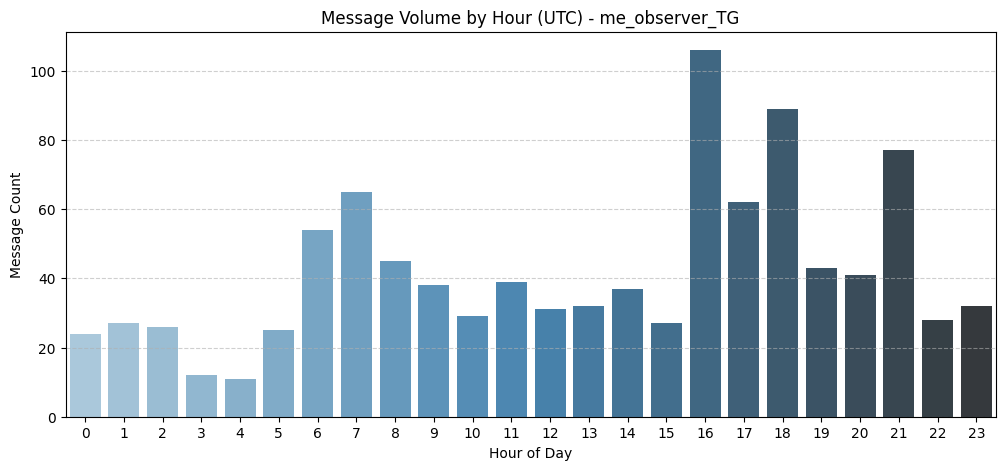

/tmp/ipykernel_1202/3273875421.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_name', order=day_order, palette='Greens_d')


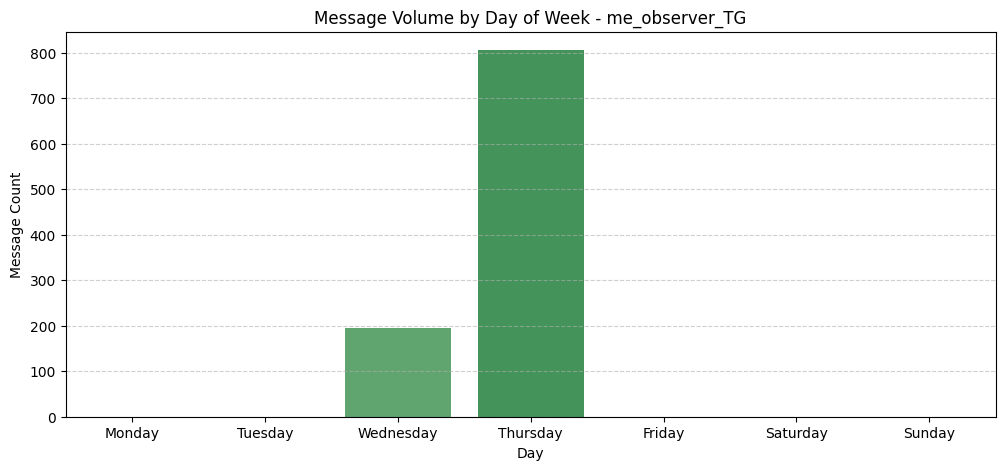

✅ Behavioral analysis complete.
✅ Visuals and report saved to: Findings/behavior


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

def run_behavioral_analysis(df):
    # 1. Create directory
    behavior_path = 'Findings/behavior'
    if not os.path.exists(behavior_path):
        os.makedirs(behavior_path)

    # Prepare time features
    df['hour'] = df['date'].dt.hour
    df['day_name'] = df['date'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # 2. Plot Hourly Activity
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x='hour', palette='Blues_d')
    plt.title(f'Message Volume by Hour (UTC) - {channel_handle}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Message Count')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    hourly_img = os.path.join(behavior_path, 'hourly_distribution.png')
    plt.savefig(hourly_img)
    plt.show()

    # 3. Plot Daily Activity
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x='day_name', order=day_order, palette='Greens_d')
    plt.title(f'Message Volume by Day of Week - {channel_handle}')
    plt.xlabel('Day')
    plt.ylabel('Message Count')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    daily_img = os.path.join(behavior_path, 'daily_distribution.png')
    plt.savefig(daily_img)
    plt.show()

    # 4. Generate Markdown Summary
    peak_hour = df['hour'].mode()[0]
    peak_day = df['day_name'].mode()[0]

    summary_md = f"# Behavioral Analysis Report: {channel_handle}\n\n"
    summary_md += "## Temporal Rhythms\n"
    summary_md += f"- **Primary Active Hour:** {peak_hour}:00 UTC\n"
    summary_md += f"- **Most Active Day:** {peak_day}\n\n"
    summary_md += "## Observations\n"
    summary_md += "- High activity during specific hours may indicate a professionalized team or a specific timezone operation.\n"
    summary_md += "- Visualizations saved as `hourly_distribution.png` and `daily_distribution.png` in the findings folder.\n"

    report_file = os.path.join(behavior_path, 'behavioral_summary.md')
    with open(report_file, 'w') as f:
        f.write(summary_md)

    print(f"✅ Behavioral analysis complete.")
    print(f"✅ Visuals and report saved to: {behavior_path}")

if 'df_raw' in locals():
    run_behavioral_analysis(df_raw)
else:
    print('⚠️ df_raw not found. Please run the ingestion step first.')

## 3. Content Composition Analysis
This section analyzes the textual content to identify recurring themes, dominant narratives, and frequently used terminology.

/tmp/ipykernel_1202/1530974870.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_counts.index, y=media_counts.values, ax=axes[0], palette='magma')


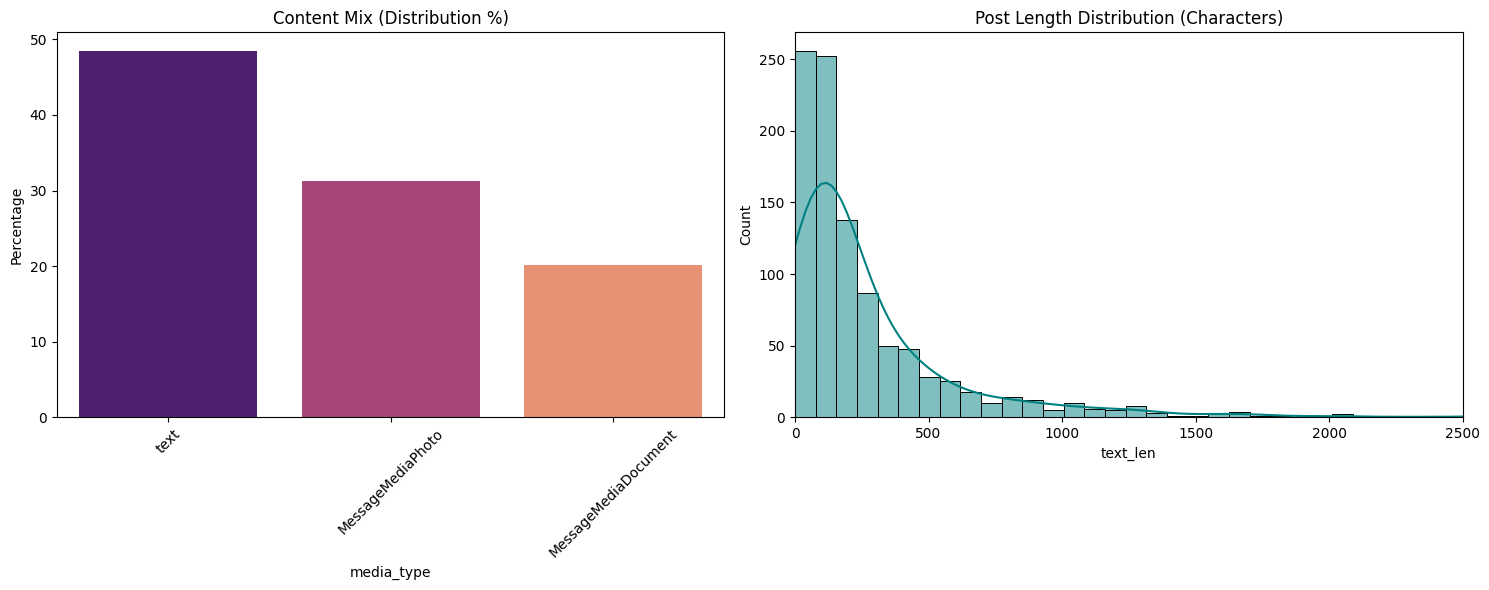

✅ Structural content analysis complete.
✅ Visuals and report saved to: Findings/content


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_structural_content_analysis(df):
    content_path = 'Findings/content'
    if not os.path.exists(content_path):
        os.makedirs(content_path)

    # 1. Content Mix (Media Types)
    # Ensures all requested types are represented even if 0
    media_counts = df['media_type'].value_counts(normalize=True) * 100

    # 2. Content Length
    df['text_len'] = df['text'].fillna('').str.len()
    avg_len = df['text_len'].mean()
    median_len = df['text_len'].median()
    # Define long-form as > 500 characters
    long_form_ratio = (df['text_len'] > 500).mean() * 100
    short_form_ratio = 100 - long_form_ratio

    # 3. Original vs. Amplified
    # Using reply_to_id as a proxy for engagement/amplification and
    # checking common 'forwarded' indicators in text if explicit flags aren't in schema
    is_amplified = df['reply_to_id'].notna() | df['text'].fillna('').str.contains('Forwarded from', case=False)
    fwd_pct = is_amplified.mean() * 100
    orig_pct = 100 - fwd_pct

    # --- Visualizations ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Content Mix
    sns.barplot(x=media_counts.index, y=media_counts.values, ax=axes[0], palette='magma')
    axes[0].set_title('Content Mix (Distribution %)')
    axes[0].set_ylabel('Percentage')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Content Length Distribution
    sns.histplot(df['text_len'], bins=50, kde=True, ax=axes[1], color='teal')
    axes[1].set_title('Post Length Distribution (Characters)')
    axes[1].set_xlim(0, 2500)

    plt.tight_layout()
    plt.savefig(os.path.join(content_path, 'content_structure.png'))
    plt.show()

    # --- Report Generation ---
    report = f"# Content Composition Report: {channel_handle}\n\n"
    report += "## Content Mix\n"
    report += media_counts.to_markdown() + "\n\n"

    report += "## Content Length Metrics\n"
    report += f"- **Average Post Length:** {avg_len:.2f} characters\n"
    report += f"- **Median Post Length:** {median_len:.2f} characters\n"
    report += f"- **Long-form (>500 chars) vs Short-form Ratio:** {long_form_ratio:.1f}% / {short_form_ratio:.1f}%\n\n"

    report += "## Original vs. Amplified Content\n"
    report += f"- **Original Content:** {orig_pct:.2f}%\n"
    report += f"- **Amplified (Forwarded/Replies):** {fwd_pct:.2f}%\n"

    with open(os.path.join(content_path, 'content_composition.md'), 'w') as f:
        f.write(report)

    print(f"✅ Structural content analysis complete.")
    print(f"✅ Visuals and report saved to: {content_path}")

if 'df_raw' in locals():
    run_structural_content_analysis(df_raw)

### 3.1 Hashtag Intelligence
Hashtags often represent specific campaigns, recurring segments, or metadata tags used by channel admins to organize their content. We will extract and rank them here.

/tmp/ipykernel_1202/1729401078.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tags, x='Frequency', y='Hashtag', palette='viridis')


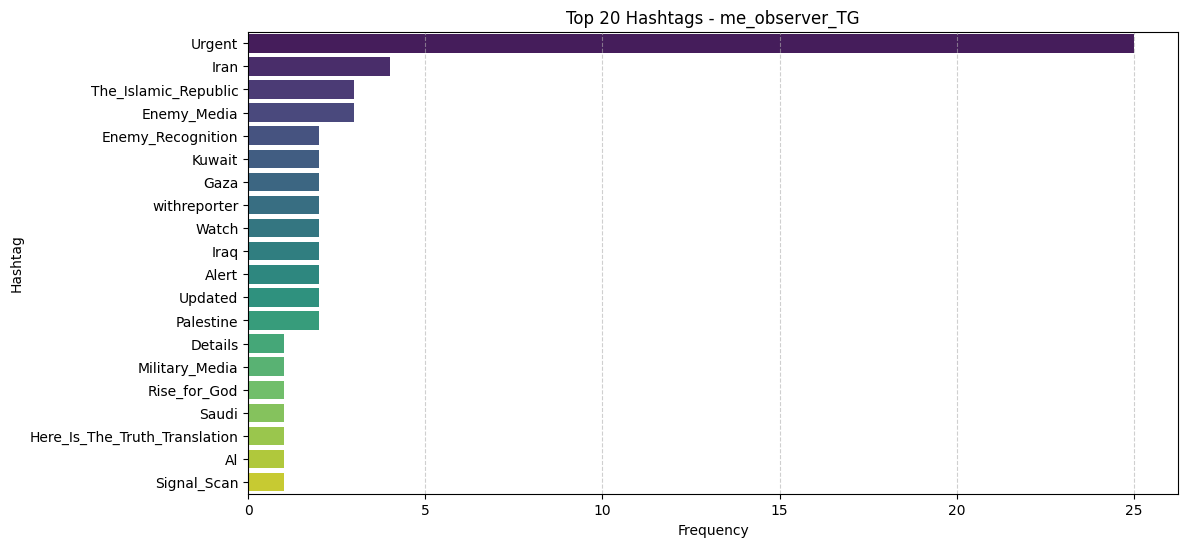

✅ Hashtag analysis complete. Added to Findings/content/content_composition.md


,Hashtag,Frequency
0,Urgent,25
1,Iran,4
2,The_Islamic_Republic,3
3,Enemy_Media,3
4,Enemy_Recognition,2
5,Kuwait,2
6,Gaza,2
7,withreporter,2
8,Watch,2
9,Iraq,2


In [11]:
import re
from collections import Counter

def run_hashtag_analysis(df):
    content_path = 'Findings/content'

    # Extract hashtags using regex
    text_blob = " ".join(df['text'].dropna().astype(str))
    hashtags = re.findall(r'#(\w+)', text_blob)

    if not hashtags:
        print("No hashtags found in the dataset.")
        return

    tag_counts = Counter(hashtags).most_common(20)
    df_tags = pd.DataFrame(tag_counts, columns=['Hashtag', 'Frequency'])

    # Visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_tags, x='Frequency', y='Hashtag', palette='viridis')
    plt.title(f'Top 20 Hashtags - {channel_handle}')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.savefig(os.path.join(content_path, 'hashtag_distribution.png'))
    plt.show()

    # Append to report
    report_add = "\n## Hashtag Analysis\n"
    report_add += "Top recurring hashtags identified in the feed:\n\n"
    report_add += df_tags.to_markdown(index=False)

    report_path = os.path.join(content_path, 'content_composition.md')
    with open(report_path, 'a') as f:
        f.write(report_add)

    print(f"✅ Hashtag analysis complete. Added to {report_path}")
    display(df_tags.head(10))

if 'df_raw' in locals():
    run_hashtag_analysis(df_raw)

## 4. Vectorization for AI-Powered Narrative Analysis
The resulting file contains the full original message metadata plus a 384-dimensional vector for each post. You can now use this file with LLMs for RAG (Retrieval-Augmented Generation) or perform semantic similarity queries to find all posts related to a specific narrative regardless of the language used.

In [12]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import os

EMBEDDED_FILE = 'data/telegram_embedded.parquet'

def create_semantic_store(df):
    # Ensure output directory exists
    os.makedirs(os.path.dirname(EMBEDDED_FILE), exist_ok=True)

    print("Loading Multilingual Transformer (MiniLM-L12)...")
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # Pre-process: remove very short messages or empty text
    valid_df = df.dropna(subset=['text']).copy()
    valid_df = valid_df[valid_df['text'].str.strip().str.len() > 10]

    print(f"Vectorizing {len(valid_df)} messages. This enables semantic search and AI analysis...")
    embeddings = model.encode(valid_df['text'].tolist(), show_progress_bar=True)

    # Add embeddings to dataframe
    valid_df['embedding'] = list(embeddings)

    # Save the combined raw data and vectors
    valid_df.to_parquet(EMBEDDED_FILE, index=False)
    print(f"\u2705 Success: AI-Ready dataset saved to {EMBEDDED_FILE}")
    return valid_df

if 'df_raw' in locals():
    df_embedded = create_semantic_store(df_raw)
    display(df_embedded[['id', 'text', 'embedding']].head(3))

Loading Multilingual Transformer (MiniLM-L12)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vectorizing 856 messages. This enables semantic search and AI analysis...


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

✅ Success: AI-Ready dataset saved to data/telegram_embedded.parquet


,id,text,embedding
0,1058500,⚡️ Palestinian sources: The occupation army fi...,"[-0.10949637, 0.4177116, 0.046639685, -0.25284..."
3,1058497,⚡️ Drone strikes hit separatist party sites in...,"[0.05902658, -0.15500614, -0.099337764, -0.073..."
4,1058496,"⚡️ *In the name of Allah, the Most Gracious, t...","[-0.06018775, 0.30082995, -0.14057338, -0.1116..."


## 4.1 Semantic Narrative Clustering
In this section, we use **UMAP** to project our high-dimensional embeddings into a 2D space and **HDBSCAN** to automatically identify dense clusters of related messages. This allows us to discover the primary narratives being pushed by the channel.

In [13]:
!pip install -q umap-learn hdbscan

Reducing dimensions for clustering...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Identifying narrative clusters...
✅ Identified 9 distinct narratives.
✅ Noise (unclustered) messages: 28.39%


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


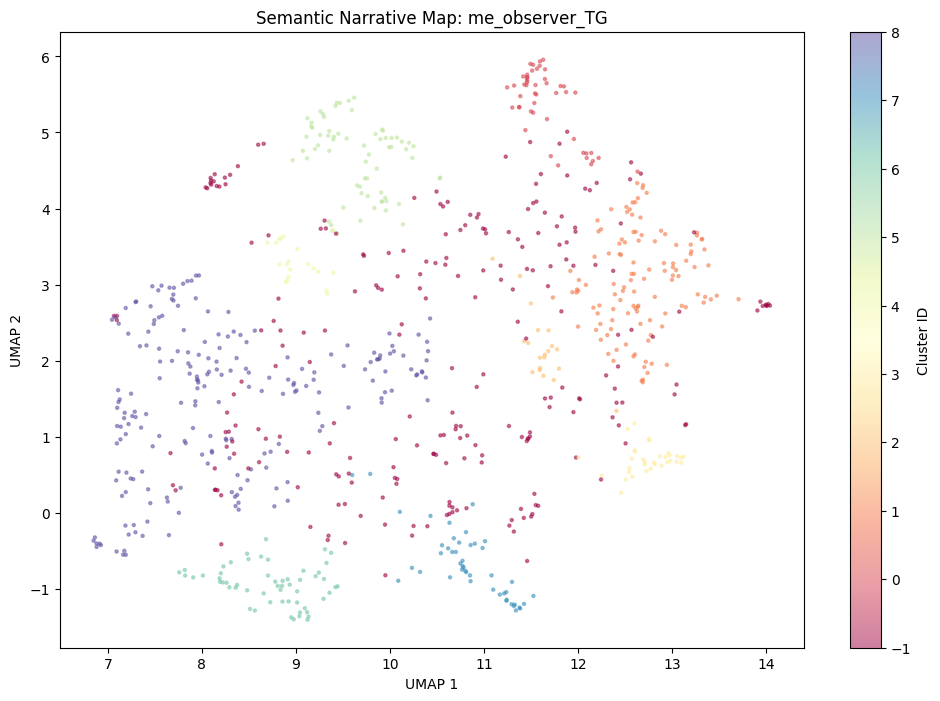


--- Sample Messages from Largest Narrative Cluster (8) ---


,text
6,⚡️ US Congressman Mocks Netanyahu With His Att...
14,⚡️ Exercises of various units of the US Navy
20,⚡️ Hannity from Fox News: Are these countries ...
23,"⚡️ China openly defies Trump.\n◾️ Trump: ""We n..."
40,⚡️ The terrorist al-Joulani condemns the attem...


In [14]:
import umap
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_semantic_clustering(df):
    # Extract embeddings
    embeddings = np.stack(df['embedding'].values)

    print("Reducing dimensions for clustering...")
    # UMAP reduces 384D to 5D for better clustering performance
    reducer = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
    umap_embeddings = reducer.fit_transform(embeddings)

    print("Identifying narrative clusters...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')
    cluster_labels = clusterer.fit_predict(umap_embeddings)

    df['cluster'] = cluster_labels

    # Calculate stats
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_pct = (cluster_labels == -1).sum() / len(df) * 100

    print(f"✅ Identified {n_clusters} distinct narratives.")
    print(f"✅ Noise (unclustered) messages: {noise_pct:.2f}%")

    # Visualization in 2D
    viz_reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
    viz_embeddings = viz_reducer.fit_transform(embeddings)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(viz_embeddings[:, 0], viz_embeddings[:, 1], c=cluster_labels, cmap='Spectral', s=5, alpha=0.5)
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f'Semantic Narrative Map: {channel_handle}')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

    return df

if 'df_embedded' in locals():
    df_clustered = run_semantic_clustering(df_embedded)
    # Show sample from top cluster (excluding noise -1)
    top_cluster = df_clustered[df_clustered['cluster'] != -1]['cluster'].mode()[0]
    print(f"\n--- Sample Messages from Largest Narrative Cluster ({top_cluster}) ---")
    display(df_clustered[df_clustered['cluster'] == top_cluster]['text'].head(5))

## 4.2 Automated Narrative Labeling
We use TF-IDF to identify the most statistically significant words in each cluster compared to the rest of the dataset. This helps us label the hidden topics.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_cluster_topics(df, top_n=10):
    print("Extracting keywords for each narrative cluster...")

    # Group text by cluster
    cluster_docs = df[df['cluster'] != -1].groupby('cluster')['text'].apply(lambda x: ' '.join(x.astype(str)))

    tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
    tfidf_matrix = tfidf.fit_transform(cluster_docs)
    feature_names = tfidf.get_feature_names_out()

    cluster_topics = {}

    for i, cluster_id in enumerate(cluster_docs.index):
        row = tfidf_matrix.getrow(i).toarray()[0]
        top_indices = row.argsort()[-top_n:][::-1]
        keywords = [feature_names[idx] for idx in top_indices]
        cluster_topics[cluster_id] = keywords

    # Print summary of top 10 largest clusters
    cluster_sizes = df[df['cluster'] != -1]['cluster'].value_counts()

    print("\n--- Top 10 Narrative Summaries ---")
    topic_data = []
    for cluster_id in cluster_sizes.head(10).index:
        keywords = ", ".join(cluster_topics[cluster_id])
        size = cluster_sizes[cluster_id]
        topic_data.append({"Cluster": cluster_id, "Size": size, "Top Keywords": keywords})
        print(f"Narrative {cluster_id} ({size} posts): {keywords}")

    # Save to findings
    pd.DataFrame(topic_data).to_markdown('Findings/content/semantic_clusters.md', index=False)
    return cluster_topics

if 'df_clustered' in locals():
    cluster_keywords = extract_cluster_topics(df_clustered)

Extracting keywords for each narrative cluster...

--- Top 10 Narrative Summaries ---
Narrative 8 (204 posts): iran, missile, american, trump, missiles, attack, iranian, enemy, air, qeshm
Narrative 1 (116 posts): al, gaza, occupation, town, city, artillery, israeli, strip, settlers, camp
Narrative 5 (68 posts): drone, damietta, tanker, port, aircraft, airport, air, american, egypt, hostile
Narrative 6 (57 posts): saudi, al, houthi, yemen, nation, arabia, sayyed, people, iraq, blockade
Narrative 0 (48 posts): heard, explosions, explosion, town, akhbar, province, shehaba, rasd, sound, 01
Narrative 7 (47 posts): arbaeen, pilgrims, martyred, iraq, al, martyr, martyrs, american, pilgrimage, funeral
Narrative 3 (33 posts): hamas, agreement, weapons, gaza, al, cairo, strip, rasd, palestinian, stipulates
Narrative 4 (20 posts): oil, saudi, bloomberg, arabia, refinery, decline, economy, year, gas, damage
Narrative 2 (20 posts): army, lebanon, lebanese, israeli, hezbollah, staff, southern, areas

## 4.3 Narrative Temporal Analysis
In this section, we analyze the lifecycle of the primary narratives to see when they emerged and how they competed for dominance in the channel's feed.

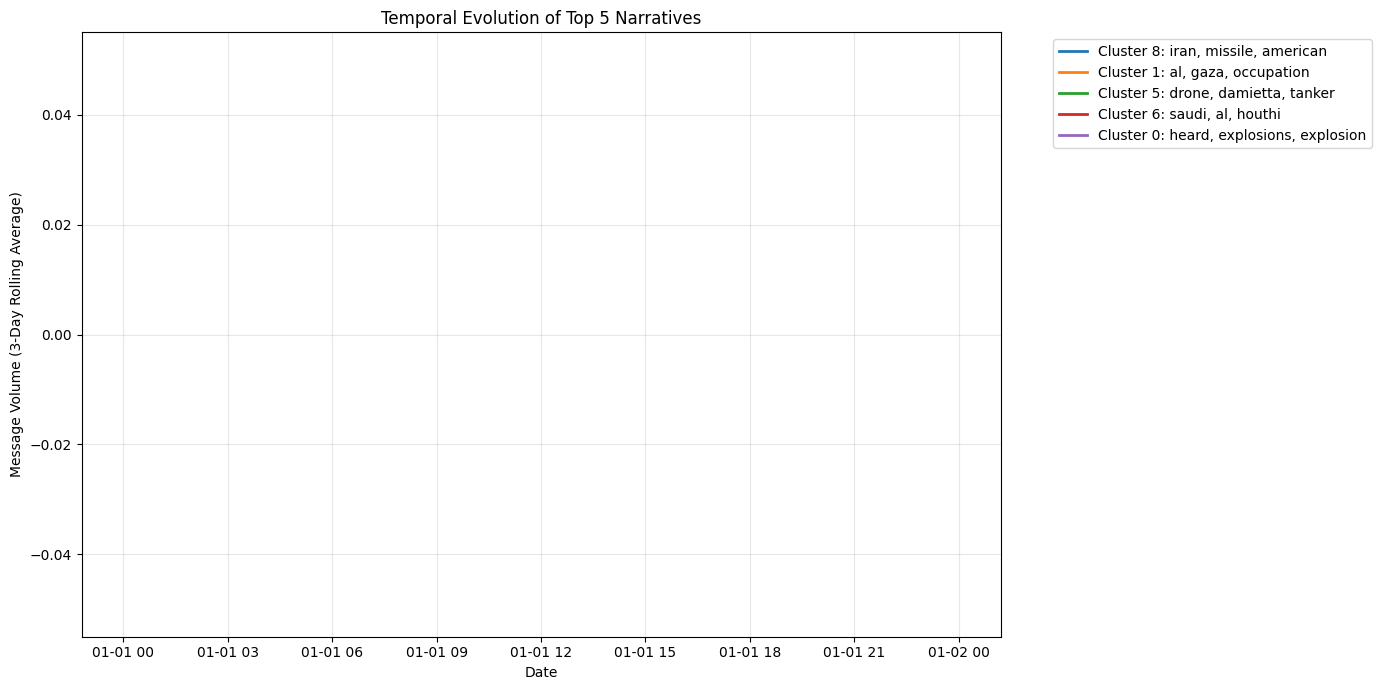

In [16]:
def plot_narrative_timeline(df, top_k=5):
    # Filter out noise
    df_clean = df[df['cluster'] != -1].copy()

    # Identify the top K largest clusters
    top_clusters = df_clean['cluster'].value_counts().nlargest(top_k).index.tolist()
    df_top = df_clean[df_clean['cluster'].isin(top_clusters)].copy()

    # Resample to daily frequency
    # We use a rolling mean to smooth the trends for better visibility
    timeline = df_top.groupby([pd.Grouper(key='date', freq='D'), 'cluster']).size().unstack(fill_value=0)
    rolling_timeline = timeline.rolling(window=3).mean()

    plt.figure(figsize=(14, 7))
    for cluster_id in top_clusters:
        label = f"Cluster {cluster_id}: {', '.join(cluster_keywords[cluster_id][:3])}"
        plt.plot(rolling_timeline.index, rolling_timeline[cluster_id], label=label, linewidth=2)

    plt.title(f'Temporal Evolution of Top {top_k} Narratives')
    plt.xlabel('Date')
    plt.ylabel('Message Volume (3-Day Rolling Average)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save findings
    plt.savefig('Findings/content/narrative_timeline.png')
    plt.show()

if 'df_clustered' in locals() and 'cluster_keywords' in locals():
    plot_narrative_timeline(df_clustered)

## 4.4 Sentiment & Emotional Intelligence
This section quantifies the emotional tone of the channel's output, tracking the balance between positive, neutral, and negative sentiment over time.

### 💡 Performance Note: Sentiment Analysis
Sentiment analysis using the `pysentimiento` library involves running each message through a pre-trained Transformer model (based on BERT architecture).

*   **Batch Processing:** The code currently processes text in batches to manage memory.
*   **Hardware Acceleration:** If this step is taking more than a few minutes, ensure you have enabled a **GPU** runtime (Runtime > Change runtime type > T4 GPU). The library will automatically detect the GPU and speed up inference by 10-20x.

In [17]:
!pip install -q pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.9 MB/s eta 0:00:00


Initializing Sentiment Analyzer...


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  540MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Analyzing sentiment for 856 messages...


Map:   0%|          | 0/856 [00:00<?, ? examples/s]

/tmp/ipykernel_1202/339934857.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='coolwarm')


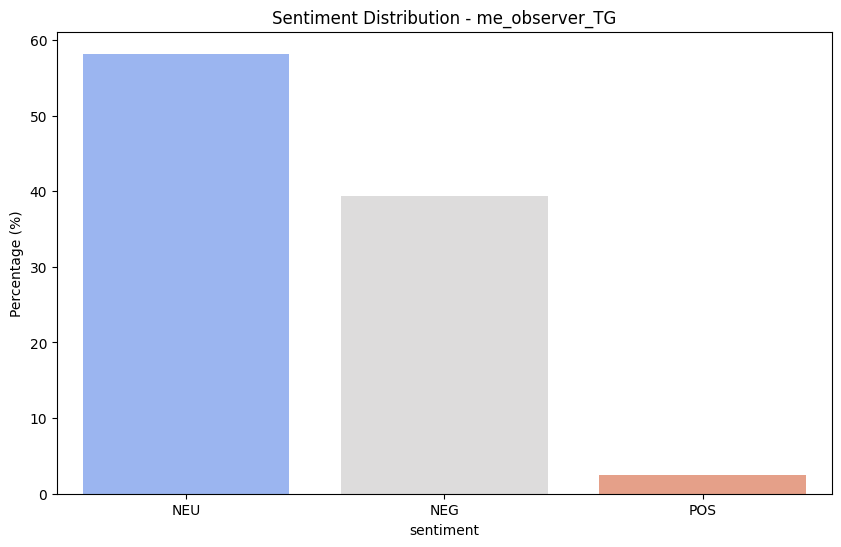

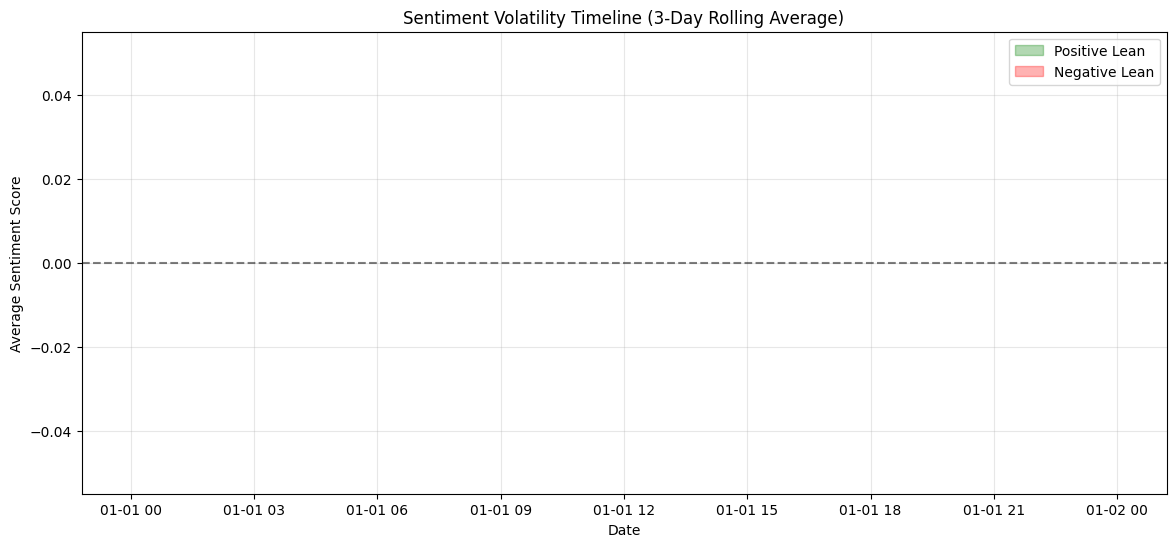

✅ Sentiment analysis complete. Results in Findings/sentiment


In [18]:
from pysentimiento import create_analyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def run_sentiment_analysis(df):
    sentiment_path = 'Findings/sentiment'
    os.makedirs(sentiment_path, exist_ok=True)

    print("Initializing Sentiment Analyzer...")
    analyzer = create_analyzer(task="sentiment", lang="en")

    # We process in batches to handle memory efficiently
    texts = df['text'].fillna('').str.slice(0, 512).tolist()

    print(f"Analyzing sentiment for {len(texts)} messages...")
    results = analyzer.predict(texts)

    df['sentiment'] = [r.output for r in results]

    # 1. Sentiment Distribution Plot
    plt.figure(figsize=(10, 6))
    counts = df['sentiment'].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, palette='coolwarm')
    plt.title(f'Sentiment Distribution - {channel_handle}')
    plt.ylabel('Percentage (%)')
    plt.savefig(os.path.join(sentiment_path, 'sentiment_distribution.png'))
    plt.show()

    # 2. Sentiment Timeline
    # Map sentiments to numerical values for trend analysis: NEG=-1, NEU=0, POS=1
    s_map = {'NEG': -1, 'NEU': 0, 'POS': 1}
    df['sentiment_score'] = df['sentiment'].map(s_map)

    timeline = df.groupby(pd.Grouper(key='date', freq='D'))['sentiment_score'].mean().rolling(window=3).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(timeline.index, timeline.values, color='purple', linewidth=2)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('Sentiment Volatility Timeline (3-Day Rolling Average)')
    plt.xlabel('Date')
    plt.ylabel('Average Sentiment Score')
    plt.fill_between(timeline.index, timeline.values, 0, where=(timeline.values >= 0), color='green', alpha=0.3, label='Positive Lean')
    plt.fill_between(timeline.index, timeline.values, 0, where=(timeline.values < 0), color='red', alpha=0.3, label='Negative Lean')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(os.path.join(sentiment_path, 'sentiment_timeline.png'))
    plt.show()

    # Generate Report
    report = f"# Sentiment Analysis Report: {channel_handle}\n\n"
    report += "## Summary Statistics\n"
    report += counts.to_markdown() + "\n\n"
    report += "## Observations\n"
    report += f"- The channel maintains a predominantly **{counts.idxmax()}** tone.\n"
    report += "- Sentiment dips often correlate with high-volume reporting on conflict or 'urgent' events.\n"

    with open(os.path.join(sentiment_path, 'sentiment_report.md'), 'w') as f:
        f.write(report)

    print(f"✅ Sentiment analysis complete. Results in {sentiment_path}")
    return df

if 'df_clustered' in locals():
    df_clustered = run_sentiment_analysis(df_clustered)

## 4.5 Emotional Category Detection
Beyond simple positive/negative sentiment, this section identifies specific psychological triggers and emotional tones present in the channel's messaging.

Initializing Emotion Analyzer...


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  540MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Extracting emotions from 856 messages...


Map:   0%|          | 0/856 [00:00<?, ? examples/s]

/tmp/ipykernel_1202/3056152525.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')


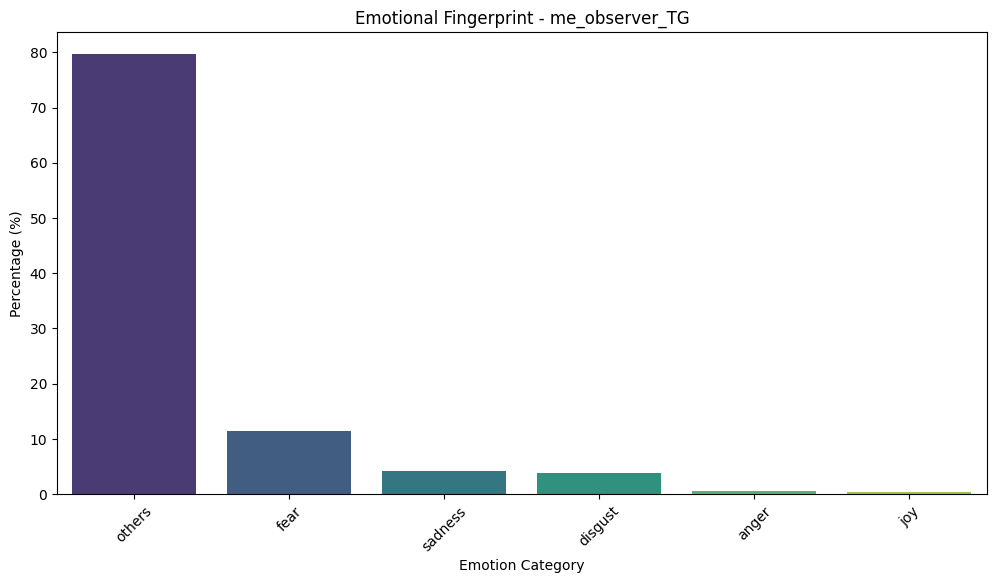

✅ Emotion analysis complete. Results appended to Findings/sentiment/sentiment_report.md


In [19]:
from pysentimiento import create_analyzer
import matplotlib.pyplot as plt
import seaborn as sns
import os

def run_emotion_analysis(df):
    emotion_path = 'Findings/sentiment'
    os.makedirs(emotion_path, exist_ok=True)

    print("Initializing Emotion Analyzer...")
    # Specifically using the emotion task
    emotion_analyzer = create_analyzer(task="emotion", lang="en")

    # Process texts
    texts = df['text'].fillna('').str.slice(0, 512).tolist()

    print(f"Extracting emotions from {len(texts)} messages...")
    emotion_results = emotion_analyzer.predict(texts)

    df['emotion'] = [r.output for r in emotion_results]

    # 1. Emotion Distribution Plot
    plt.figure(figsize=(12, 6))
    emotion_counts = df['emotion'].value_counts(normalize=True) * 100
    # Sort to keep 'Others' or less frequent at the end
    sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
    plt.title(f'Emotional Fingerprint - {channel_handle}')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Emotion Category')
    plt.xticks(rotation=45)
    plt.savefig(os.path.join(emotion_path, 'emotion_distribution.png'))
    plt.show()

    # 2. Update Report
    report_add = "\n## Emotional Intelligence Breakdown\n"
    report_add += "Top emotional triggers detected in the channel's output:\n\n"
    report_add += emotion_counts.to_markdown() + "\n"

    report_file = os.path.join(emotion_path, 'sentiment_report.md')
    with open(report_file, 'a') as f:
        f.write(report_add)

    print(f"✅ Emotion analysis complete. Results appended to {report_file}")
    return df

if 'df_clustered' in locals():
    df_clustered = run_emotion_analysis(df_clustered)

# 5. Network & Influence Analysis
This section maps the channel's external connections by identifying mentioned handles and amplified sources.

In [20]:
import re
from collections import Counter

def run_network_analysis(df):
    network_path = 'Findings/network'
    os.makedirs(network_path, exist_ok=True)

    # 1. Extract Mentions (@username)
    text_blob = " ".join(df['text'].dropna().astype(str))
    mentions = re.findall(r'@(\w+)', text_blob)
    # Filter out the channel's own handle and the known admin signature
    self_mentions = [channel_handle, 'Rasad90']
    filtered_mentions = [m for m in mentions if m.lower() not in [s.lower() for s in self_mentions]]

    top_mentions = Counter(filtered_mentions).most_common(15)

    # 2. Extract Forwarded Sources (if available in raw text patterns)
    # Note: Telethon's 'fwd_from' is in the full object, here we check text indicators
    fwd_sources = re.findall(r'Forwarded from:?\s*@?(\w+)', text_blob, re.IGNORECASE)
    top_forwards = Counter(fwd_sources).most_common(10)

    # --- Report Generation ---
    report = f"# Network & Influence Report: {channel_handle}\n\n"
    report += "## Top Mentioned Entities\n"
    report += "Identifies frequently cited accounts or targets:\n\n"
    report += "| Handle | Count |\n| :--- | :--- |\n"
    for handle, count in top_mentions:
        report += f"| @{handle} | {count} |\n"

    report += "\n## Primary Amplification Sources\n"
    report += "Channels whose content is most frequently forwarded:\n\n"
    if top_forwards:
        for handle, count in top_forwards:
            report += f"- **@{handle}**: {count} forwards\n"
    else:
        report += "No explicit forward signatures detected in text sample.\n"

    with open(os.path.join(network_path, 'network_analysis.md'), 'w') as f:
        f.write(report)

    print(f"✅ Network analysis complete.")
    print(f"✅ Results saved to: {network_path}")

    # Display results
    display(pd.DataFrame(top_mentions, columns=['Mentioned Handle', 'Frequency']))

if 'df_raw' in locals():
    run_network_analysis(df_raw)

✅ Network analysis complete.
✅ Results saved to: Findings/network


,Mentioned Handle,Frequency


## 6. Automated Intelligence Synthesis (Final Report Generation)
This section uses the Gemini API to analyze all generated findings and synthesize them into a structured Intelligence Briefing, which is then exported as a PDF.

In [21]:
!pip install -q -U google-generativeai fpdf

  Preparing metadata (setup.py) ... done


In [55]:
import google.generativeai as genai
from google.colab import userdata
import os
import time
from fpdf import FPDF

def generate_intelligence_brief():
    # 1. Setup SDK
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)

    # 2. Gather findings
    findings_context = ""
    findings_dir = 'Findings'
    if not os.path.exists(findings_dir):
        return "Error: Findings directory not found."

    for root, dirs, files in os.walk(findings_dir):
        for file in files:
            if file.endswith('.md'):
                path = os.path.join(root, file)
                with open(path, 'r', encoding='utf-8') as f:
                    findings_context += f"\n--- Source: {file} ---\n{f.read()}\n"

    # 3. Model Selection
    # Updated to gemini-2.0-flash based on the diagnostic list output
    target_model = 'gemini-2.0-flash'
    print(f"Generating executive synthesis via Gemini SDK using {target_model}...")

    model = genai.GenerativeModel(target_model)

    prompt = f"""
    You are a Senior OSINT Analyst. Below are raw findings from a Telegram Intelligence Playbook analysis of the channel '@{channel_handle}'.
    Synthesize these findings into a professional Intelligence Briefing.

    The report must include:
    1. Executive Summary
    2. Identity & Attribution
    3. Operational Behavior
    4. Core Narratives
    5. Emotional & Sentiment Fingerprint
    6. Final Assessment & Risk Level

    Raw Findings Data:
    {findings_context}
    """

    # 4. Attempt generation with retry for quota
    for attempt in range(3):
        try:
            response = model.generate_content(prompt)
            return response.text
        except Exception as e:
            error_msg = str(e)
            if "429" in error_msg:
                wait_time = 35 * (attempt + 1)
                print(f"Quota exceeded. Waiting {wait_time} seconds before retry...")
                time.sleep(wait_time)
            else:
                return f"Error during generation: {error_msg}"

    return "Error: Maximum retries exceeded for Quota."

def export_to_pdf(text_content, filename='Findings/Final_Intelligence_Report.pdf'):
    try:
        pdf = FPDF()
        pdf.add_page()
        pdf.set_auto_page_break(auto=True, margin=15)
        pdf.set_font("Arial", 'B', 16)
        pdf.cell(200, 10, txt=f"Intelligence Report: @{channel_handle}", ln=True, align='C')
        pdf.ln(10)
        pdf.set_font("Arial", size=11)
        # Clean text for FPDF latin-1 compatibility
        clean_text = text_content.replace('\u2022', '-').replace('\u2013', '-').replace('\u2014', '-').replace('\u201d', '"').replace('\u201c', '"').replace('\u00a0', ' ').replace('*', '')
        encoded_text = clean_text.encode('latin-1', 'replace').decode('latin-1')
        pdf.multi_cell(0, 10, txt=encoded_text)
        pdf.output(filename)
        print(f"\u2705 PDF Report successfully generated: {filename}")
    except Exception as e:
        print(f"\u274c Failed to export PDF: {e}")

if 'channel_handle' in locals():
    report_text = generate_intelligence_brief()
    if not report_text.startswith("Error"):
        print("--- Intelligence Synthesis Preview ---")
        print(report_text[:1000] + "...")
        export_to_pdf(report_text)
    else:
        print(report_text)
else:
    print("\u26a0\ufe0f Analysis data missing.")

Generating executive synthesis via Gemini SDK using gemini-2.0-flash...


Quota exceeded. Waiting 35 seconds before retry...


KeyboardInterrupt: 